# Dimensionamiento del brazo: geometría, servos y resorte compensador

**Taller de Proyecto I (E0306) — 2.º cuatrimestre 2026 — Grupo N.º 4**

---

## Por qué escribimos esto

En el informe inicial dejamos varios valores marcados como *«a determinar en la
fase de diseño»*. Este cuaderno es el trabajo que hicimos para cerrar dos de
ellos:

1. **La geometría del brazo**: cuánto mide cada eslabón.
2. **Los servos**: qué par necesita cada articulación.

Queremos aclarar de entrada qué tipo de trabajo es este, porque nos lo
preguntamos entre nosotros antes de arrancar. No es un estudio mecánico
completo, y lo decidimos así a propósito. Somos una carrera de Ingeniería en
Computación: la profundidad del proyecto está en el firmware, la máquina de
estados y el control coordinado de ejes. La parte mecánica la necesitamos **bien
dimensionada y bien justificada**, no la necesitamos exhaustiva.

Así que buscamos el cálculo más simple que siguiera siendo defendible, y usamos
el criterio clásico de ingeniería para cuando uno no puede modelar con
precisión: **calcular el peor caso y comprar margen**.

Todo lo que sigue usa únicamente la librería `math`. No hace falta instalar nada
para correrlo.

---

# 1. Cómo es el brazo que estamos dimensionando

Antes de cualquier cuenta, esto es lo que estamos calculando. Los nombres de
cada parte (hombro, codo, muñeca) los usamos en todo el documento.

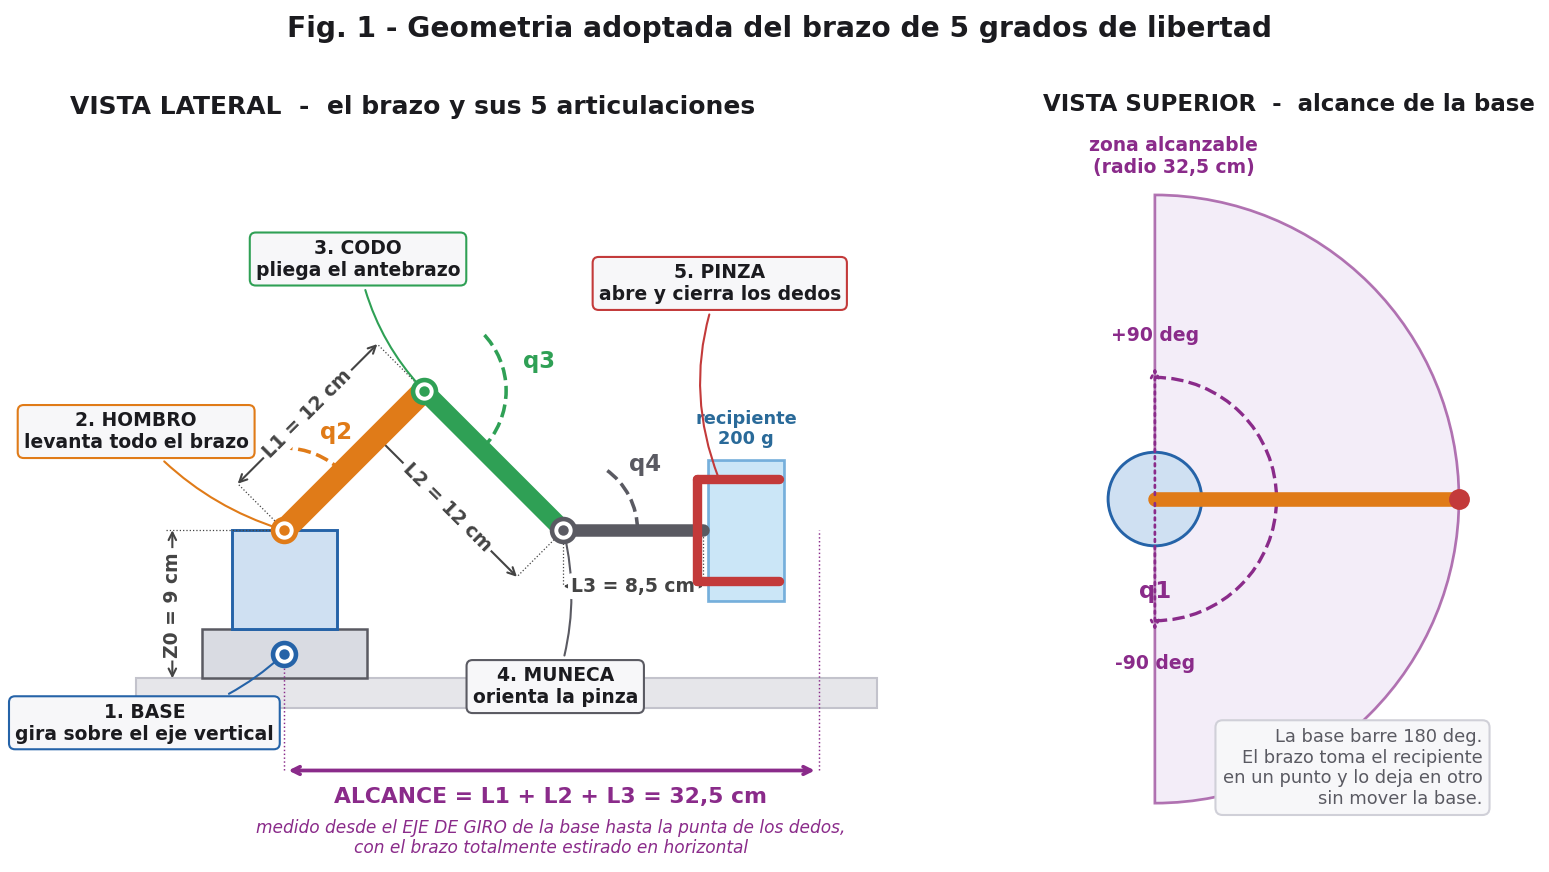

**Cómo leer las dimensiones.** Cada longitud va **de un eje de giro al
siguiente**, no de punta a punta de la pieza:

| Símbolo | Desde | Hasta | Valor |
|---|---|---|---|
| `Z0` | la mesa | el eje del hombro | 9 cm |
| `L1` | el eje del **hombro** | el eje del **codo** | 12 cm |
| `L2` | el eje del **codo** | el eje de la **muñeca** | 12 cm |
| `L3` | el eje de la **muñeca** | la punta de los dedos | 8,5 cm |

El **alcance** es la suma `L1 + L2 + L3 = 32,5 cm`, medida desde el eje de giro
de la base hasta la punta de los dedos, con el brazo totalmente estirado en
horizontal. `Z0` no entra en el alcance porque es una altura, no una distancia
horizontal: lo que hace es levantar todo el brazo sobre la mesa para que la
pinza pueda bajar a agarrar el recipiente sin chocar contra ella.

**Las cinco articulaciones**, con el nombre que les damos en el código:

| # | Nombre | Variable | Qué hace | Eje |
|---|---|---|---|---|
| 1 | Base | `q1` | gira el brazo entero para barrer el plano de la mesa | vertical |
| 2 | Hombro | `q2` | levanta y baja todo el brazo | horizontal |
| 3 | Codo | `q3` | pliega el antebrazo contra el brazo | horizontal |
| 4 | Muñeca | `q4` | orienta la pinza para que el recipiente quede derecho | horizontal |
| 5 | Pinza | `q5` | abre y cierra los dedos | lineal |

Medimos `q2`, `q3` y `q4` **desde la vertical**: 0° es el brazo parado hacia
arriba, 90° es el brazo horizontal. Esa convención nos sirve para más adelante,
porque hace que el par gravitatorio quede como un seno limpio.

---

# 2. El punto de partida

La tarea del proyecto es trasladar un recipiente con líquido de un punto a otro
con el brazo comandado por joystick, sin tocarlo con las manos.

De esa tarea sacamos dos números, y todo lo demás depende de ellos:

| Dato | Valor que adoptamos | De dónde sale |
|---|---|---|
| Masa del recipiente lleno | **200 g** | lo fijamos nosotros como especificación |
| Alcance horizontal | **32,5 cm** | de la comparación de la sección 8 |

Sobre la masa, queremos ser claros: **200 g es un requerimiento que fijamos
nosotros, no una medición**. Un vaso plástico de 55 mm con unos 60 mm de agua
pesa alrededor de 180 g, así que 200 g es ese vaso con algo de margen. Lo
dejamos en un número redondo a propósito: el ensayo de validación lo vamos a
hacer con una pesa de 200 g y así no discutimos decimales. Cuando elijamos el
recipiente definitivo lo vamos a pesar, y lo único que tenemos que verificar es
que no se pase de ese valor.

---

# 3. El método que elegimos: estática en el peor caso

El par que tiene que hacer un servo depende de la pose del brazo. En principio
habría que revisar todas. Nos dimos cuenta de que no hace falta, por tres
razones.

### 3.1 El peor caso es una sola pose

El momento que produce un peso respecto de un eje es

$$\tau = m \cdot g \cdot d$$

donde $d$ es la distancia **horizontal** del peso al eje, no la distancia en
línea recta. Si el peso está justo encima del eje, $d = 0$ y el momento es nulo.
Es el motivo por el que una escalera parada se sostiene sola y acostada no.

Entonces $d$ se hace máxima cuando el brazo está **totalmente estirado en
horizontal**: todos los pesos, al mismo tiempo, a su distancia máxima del eje.
No existe una pose peor, y no hay que calcular nada para saberlo.

Con eso pasamos de barrer todo el espacio de trabajo a resolver una sola cuenta.

### 3.2 En esa pose el par es una suma de «peso × distancia»

Nada más que eso. Usamos dos simplificaciones que no son aproximaciones:

- Una barra homogénea de masa $m$ y largo $L$ produce el mismo momento que esa
  misma masa concentrada en $L/2$. Es un resultado exacto para una barra de
  sección constante.
- Cada servo montado en una articulación cuenta con toda su masa a la distancia
  de esa articulación.

### 3.3 Solo calculamos el peso, y no la parte de movimiento


El par que tiene que hacer un servo se puede separar en cuatro partes:

$$\text{par} \;=\; \underbrace{\text{acelerar el brazo}}_{\text{inercia}} \;+\; \underbrace{\text{que varias articulaciones se muevan a la vez}}_{\text{Coriolis}} \;+\; \underbrace{\text{sostener el peso}}_{\text{gravedad}} \;+\; \underbrace{\text{vencer el rozamiento}}_{\text{fricción}}$$

**Nosotros calculamos solamente la tercera: sostener el peso.** Las otras tres
las despreciamos, y en 3.4 mostramos por qué nos lo podemos permitir.

Escrita de forma compacta, esa misma frase es la ecuación estándar de la
dinámica de un brazo robótico, que es como aparece en la bibliografía:

$$\tau = M(q)\,\ddot q \;+\; C(q,\dot q)\,\dot q \;+\; G(q) \;+\; F(\dot q)$$

Los símbolos, uno por uno:

| Símbolo | Qué es | En criollo |
|---|---|---|
| $q$ | los ángulos de las articulaciones | dónde está el brazo ahora: $(q_1, q_2, q_3, q_4)$ |
| $\dot q$ | la derivada de $q$ respecto del tiempo | la **velocidad** de cada articulación |
| $\ddot q$ | la derivada segunda | la **aceleración** de cada articulación |
| $\tau$ | los pares | lo que tiene que hacer cada servo |
| $M(q)\,\ddot q$ | término de inercia | lo que cuesta acelerar. Se escribe $M(q)$ y no $M$ porque depende de la pose: el brazo estirado cuesta más de acelerar que plegado |
| $C(q,\dot q)\,\dot q$ | Coriolis y centrífugos | pares que aparecen porque varias articulaciones se mueven a la vez y se empujan entre sí. Van con la velocidad al cuadrado |
| $G(q)$ | gravedad | el peso del brazo. **Es lo único que calculamos** |
| $F(\dot q)$ | fricción | rozamiento en engranajes y rodamientos |

> Los puntos sobre la $q$ son **derivadas respecto del tiempo**: es la notación
> de Newton, que se usa en mecánica para no escribir $dq/dt$ todo el tiempo.
> Un punto es velocidad, dos puntos es aceleración.

Dejamos la ecuación escrita a propósito, aunque usemos un solo término: un
cálculo que no dice qué está despreciando no se puede revisar.

### 3.4 Por qué podemos despreciar la parte de movimiento

Todo depende de una sola cosa: **qué tan rápido movemos el brazo**. Y lo movemos
muy despacio, porque el recipiente lleva líquido.

Comparemos las dos partes. Para una misma masa a una misma distancia:

- sostener el peso cuesta un par proporcional a $g = 9{,}81$ m/s²;
- acelerarla cuesta un par proporcional a la aceleración $a$ del movimiento.

O sea que **la parte de movimiento pesa, frente a la de gravedad, exactamente lo
que pesa $a$ frente a $g$**. Si $a$ resulta ser una fracción chica de $g$, la
podemos tirar.

Así que la pregunta se reduce a: ¿cuánto acelera nuestro brazo?

Nuestra tarea tiene tres tramos, y en todos arrancamos y frenamos de a poco
(nunca de golpe, justamente para no volcar el líquido). Para ese tipo de
movimiento, recorrer una distancia $d$ en un tiempo $T$ da una aceleración
máxima de

$$a_{\max} = 5{,}77 \cdot \frac{d}{T^{2}}$$

El 5,77 es una constante de la curva de arranque y frenado que usamos; cuanto
más suave es la curva, más chico es ese número. Lo importante de la fórmula es
otra cosa: **el tiempo está al cuadrado**, así que tomarse el doble de tiempo
divide la aceleración por cuatro.

In [1]:
import math
G = 9.81                    # m/s2 - lo repetimos para que esta seccion se lea sola

# Los tres tramos del movimiento: cuanto se desplaza la punta en horizontal
# y en cuanto tiempo. Son los tiempos que fijamos al disenar la trayectoria.
TRAMOS = [
    ("acercarse al recipiente", 0.11, 2.0),
    ("trasladarlo",             0.22, 4.0),
    ("volver a la posicion de reposo", 0.11, 2.0),
]
K_PERFIL = 5.77             # constante de la curva de arranque y frenado suaves

print(f"{'tramo':>32} {'distancia':>10} {'tiempo':>8} {'a maxima':>12} {'a/g':>7}")
print('-' * 74)
peor = 0.0
for nombre, d, T in TRAMOS:
    a = K_PERFIL * d / T**2
    peor = max(peor, a)
    print(f"{nombre:>32} {d*100:8.0f} cm {T:6.1f} s {a:9.3f} m/s2 {a/G*100:6.1f} %")

print(f"\nLa peor aceleracion de toda la tarea es {peor:.3f} m/s2, "
      f"un {peor/G*100:.1f} % de la gravedad.")

                           tramo  distancia   tiempo     a maxima     a/g
--------------------------------------------------------------------------
         acercarse al recipiente       11 cm    2.0 s     0.159 m/s2    1.6 %
                     trasladarlo       22 cm    4.0 s     0.079 m/s2    0.8 %
  volver a la posicion de reposo       11 cm    2.0 s     0.159 m/s2    1.6 %

La peor aceleracion de toda la tarea es 0.159 m/s2, un 1.6 % de la gravedad.


El tramo que manda **no es el traslado sino el acercamiento**: son 11 cm en 2 s
contra 22 cm en 4 s, y como el tiempo entra al cuadrado, el tramo corto y rápido
resulta más exigente que el largo y lento.

El resultado es **0,16 m/s², un 1,6 % de la gravedad**. Para tener una idea de
lo chico que es: con esa aceleración la superficie del líquido dentro del vaso
se inclina menos de un grado.

Y el factor de seguridad que vamos a adoptar es del 100 %. O sea que lo que
despreciamos entra unas sesenta veces dentro del margen que dejamos. El término
de Coriolis es todavía menor, porque va con la velocidad al cuadrado y la
velocidad también es baja.

Es un argumento de orden de magnitud, no una cota exacta, pero con esa diferencia
de escala alcanza y sobra.

Lo que más nos gustó de este razonamiento es que **las dos mitades del problema
se sostienen entre sí**: el líquido nos obliga a movernos despacio, y movernos
despacio es justamente lo que nos habilita a ignorar la dinámica. La restricción
del problema nos regaló la simplificación del cálculo.

### El límite que esto le pone al firmware

Como la fórmula es tan simple, la podemos dar vuelta y sacar un criterio
concreto: si queremos que la parte de movimiento se mantenga por debajo del 5 %
de la gravedad, cada tramo tiene un tiempo mínimo.

In [2]:
LIMITE = 0.05               # aceptamos hasta un 5 % de la gravedad
a_limite = LIMITE * G

print(f"Aceleracion maxima que nos permitimos: {a_limite:.2f} m/s2 "
      f"({LIMITE*100:.0f} % de g)\n")
for d in (0.11, 0.22, 0.30):
    T_min = math.sqrt(K_PERFIL * d / a_limite)
    print(f"  un tramo de {d*100:2.0f} cm no puede hacerse en menos de "
          f"{T_min:.1f} s")

Aceleracion maxima que nos permitimos: 0.49 m/s2 (5 % de g)

  un tramo de 11 cm no puede hacerse en menos de 1.1 s
  un tramo de 22 cm no puede hacerse en menos de 1.6 s
  un tramo de 30 cm no puede hacerse en menos de 1.9 s


Eso es un **requerimiento para el firmware**, no un dato suelto: el programa que
genera las trayectorias tiene que respetar esos tiempos mínimos. Si alguien
acelera el brazo más que eso, no solo se vuelca el líquido: además deja de valer
el dimensionamiento de los servos que hicimos acá.

> **Condición de validez.** Todo este cuaderno supone que el brazo se mueve con
> los tiempos de la tabla de arriba. Si más adelante decidimos moverlo más
> rápido, hay que rehacer la verificación. Lo dejamos escrito para no
> olvidarnos.

---

# 4. Datos de entrada

Estos son los únicos números que tuvimos que estimar. Todo el resto se calcula a
partir de ellos.

In [3]:
import math

G = 9.81                    # m/s2

# ---- La carga ------------------------------------------------------------
M_CARGA = 0.200             # kg - recipiente lleno (lo fijamos nosotros)

# ---- Geometria -----------------------------------------------------------
L1 = 0.120                  # m - eje del hombro -> eje del codo
L2 = 0.120                  # m - eje del codo   -> eje de la muneca
L3 = 0.085                  # m - eje de la muneca -> punta de los dedos

# ---- Masas de la estructura ---------------------------------------------
# Perfil de aluminio en U de 20x10 mm: ~0.35 kg por metro.
DENSIDAD_LINEAL = 0.35      # kg/m de eslabon
M_HERRAJE       = 0.010     # kg de tornilleria por articulacion
M_PINZA         = 0.090     # kg de la pinza completa, incluido su servo

# ---- Criterio de diseno --------------------------------------------------
FS = 2.0                    # factor de seguridad sobre el par nominal

# ---- Servos: clases comerciales de par y su masa tipica ------------------
# Trabajamos por CLASE de par, sin nombrar modelos ni precios: todavia no
# estamos en etapa de compra. La masa importa porque un servo de mas par es
# fisicamente mas grande (ver seccion 6).
CLASES = [(9, 0.055), (11, 0.055), (15, 0.065),
          (20, 0.065), (25, 0.150), (35, 0.150), (60, 0.250)]

def a_kgcm(nm):
    """N*m -> kg*cm, que es la unidad en que se venden los servos."""
    return nm * 100.0 / G

def clase_necesaria(par_nm):
    """La clase mas chica que cumple el factor de seguridad."""
    requerido = a_kgcm(par_nm) * FS
    for c, m in CLASES:
        if c >= requerido:
            return c, m
    return None, None

print(f"Carga adoptada: {M_CARGA*1000:.0f} g")
print(f"Alcance: {(L1+L2+L3)*100:.1f} cm")
print(f"Factor de seguridad: {FS:.1f}")

Carga adoptada: 200 g
Alcance: 32.5 cm
Factor de seguridad: 2.0


**Una aclaración sobre la unidad kg·cm.** Los servos no se especifican en N·m
sino en kg·cm, que quiere decir *«sostiene 1 kg colgado a 1 cm del eje»*. Como
es masa × distancia sin la gravedad, en la práctica podemos sumar directamente
kg × cm y saltearnos la $g$. Lo mencionamos porque al principio nos confundió.

---

# 5. El par en cada articulación

Con el brazo estirado en horizontal, cada articulación carga solamente lo que
queda **hacia afuera** de ella: el hombro carga todo, el codo carga del codo
para afuera, y la muñeca carga solo la pinza y el recipiente.

Hay un detalle que nos parece importante señalar, porque es la clave de la
sección 6: el servo que mueve una articulación está montado *en* esa
articulación, o sea a distancia cero de su propio eje. **Un servo no se pesa a
sí mismo.** Pero sí pesa, y mucho, para todas las articulaciones que quedan
hacia adentro.

Esta figura es la cuenta dibujada:

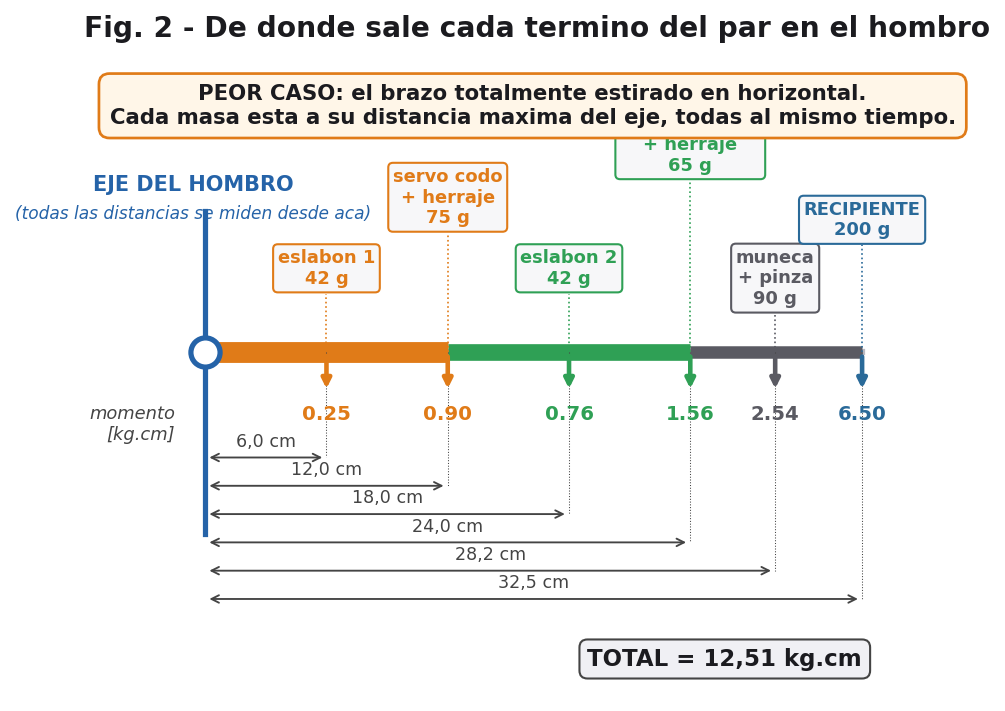

In [4]:
def pares(m_servo_codo, m_servo_muneca, m_carga=M_CARGA, detalle=False):
    """Par estatico en hombro, codo y muneca con el brazo horizontal [N*m]."""
    m1 = DENSIDAD_LINEAL * L1          # eslabon 1
    m2 = DENSIDAD_LINEAL * L2          # eslabon 2

    # --- HOMBRO: lo carga todo -------------------------------------------
    terminos = [
        ("eslabon 1 (brazo)",      m1,                         L1 / 2),
        ("servo codo + herraje",   m_servo_codo + M_HERRAJE,   L1),
        ("eslabon 2 (antebrazo)",  m2,                         L1 + L2 / 2),
        ("servo muneca + herraje", m_servo_muneca + M_HERRAJE, L1 + L2),
        ("muneca + pinza",         M_PINZA,                    L1 + L2 + L3 / 2),
        ("RECIPIENTE",             m_carga,                    L1 + L2 + L3),
    ]
    suma = sum(m * d for _, m, d in terminos)

    if detalle:
        print(f"{'':24} {'masa':>8} {'distancia':>11} {'momento':>11}")
        for n, m, d in terminos:
            print(f"{n:24} {m*1000:6.0f} g {d*100:9.1f} cm "
                  f"{m*d*100:8.2f} kg.cm  ({m*d/suma*100:4.1f} %)")
        print(f"{'TOTAL':24} {'':8} {'':11} {suma*100:8.2f} kg.cm")

    t_hombro = G * suma
    t_codo = G * (m2 * (L2 / 2) + (m_servo_muneca + M_HERRAJE) * L2
                  + M_PINZA * (L2 + L3 / 2) + m_carga * (L2 + L3))
    t_muneca = G * (M_PINZA * (L3 / 2) + m_carga * L3)
    return t_hombro, t_codo, t_muneca

---

# 6. La masa de los servos se realimenta

Acá nos tropezamos con algo que casi se nos pasa por alto. Al principio pusimos
una masa fija de 55 g para cualquier servo, y está mal: **un servo de más par es
físicamente más grande y más pesado**. Uno estándar de 11 kg·cm pesa unos 55 g,
uno de la clase 15–20 ronda los 65 g, y los de 25–35 kg·cm pueden pasar los
150 g.

Eso arma un lazo: elegimos un servo más grande, agrega peso, el peso pide más
par, y el par pide un servo más grande todavía.

Lo resolvimos **iterando**: suponemos masas, calculamos los pares, elegimos los
servos, recalculamos con las masas reales de esos servos, y repetimos hasta que
la elección deje de cambiar.

In [5]:
m_codo = m_muneca = 0.055          # suposicion inicial: servos chicos

for iteracion in range(5):
    th, tc, tm = pares(m_codo, m_muneca)
    c_codo,   nuevo_codo   = clase_necesaria(tc)
    c_muneca, nuevo_muneca = clase_necesaria(tm)
    print(f"vuelta {iteracion}: "
          f"codo {a_kgcm(tc):5.2f} kg.cm -> clase {c_codo:<3} | "
          f"muneca {a_kgcm(tm):5.2f} kg.cm -> clase {c_muneca:<3}")
    if (nuevo_codo, nuevo_muneca) == (m_codo, m_muneca):
        print("converge.")
        break
    m_codo, m_muneca = nuevo_codo, nuevo_muneca

print(f"\nMasa del servo del codo:    {m_codo*1000:.0f} g")
print(f"Masa del servo de la muneca: {m_muneca*1000:.0f} g")

vuelta 0: codo  6.59 kg.cm -> clase 15  | muneca  2.08 kg.cm -> clase 9  
vuelta 1: codo  6.59 kg.cm -> clase 15  | muneca  2.08 kg.cm -> clase 9  
converge.

Masa del servo del codo:    65 g
Masa del servo de la muneca: 55 g


### Lo que sacamos de esto: los servos **no** tienen que ser todos iguales

Mirando dónde queda montado cada servo respecto del eje que carga:

| Servo | Distancia al eje del hombro | Cuánto pesa para el hombro |
|---|---|---|
| Hombro | 0 cm | **nada, es gratis** |
| Codo | 12 cm | cada gramo cuenta |
| Muñeca | 24 cm | cada gramo cuenta el doble |

Y los pares requeridos ya venían bajando hacia afuera. Juntando las dos cosas,
la conclusión es bastante clara: **grande y pesado adentro, chico y liviano
afuera**. Comprar cinco servos iguales de la clase más alta sería peor que una
cascada decreciente, porque los tres de afuera se estarían cargando entre ellos
sin ninguna necesidad.

Al principio nos parecía que comprar todo igual iba a simplificar las cosas.
Resultó ser lo contrario.

---

# 7. El par sin compensación, y el problema que nos encontramos

Con los servos ya elegidos, este es el desglose completo del hombro.

In [6]:
print("PAR EN EL HOMBRO, BRAZO HORIZONTAL\n")
th, tc, tm = pares(m_codo, m_muneca, detalle=True)

print()
for nombre, par in [("hombro", th), ("codo", tc), ("muneca", tm)]:
    c, _ = clase_necesaria(par)
    print(f"{nombre:8} {a_kgcm(par):6.2f} kg.cm  x FS {FS:.0f} = "
          f"{a_kgcm(par)*FS:6.2f}  ->  clase {c} kg.cm")

PAR EN EL HOMBRO, BRAZO HORIZONTAL

                             masa   distancia     momento
eslabon 1 (brazo)            42 g       6.0 cm     0.25 kg.cm  ( 2.0 %)
servo codo + herraje         75 g      12.0 cm     0.90 kg.cm  ( 7.2 %)
eslabon 2 (antebrazo)        42 g      18.0 cm     0.76 kg.cm  ( 6.0 %)
servo muneca + herraje       65 g      24.0 cm     1.56 kg.cm  (12.5 %)
muneca + pinza               90 g      28.2 cm     2.54 kg.cm  (20.3 %)
RECIPIENTE                  200 g      32.5 cm     6.50 kg.cm  (52.0 %)
TOTAL                                            12.51 kg.cm

hombro    12.51 kg.cm  x FS 2 =  25.02  ->  clase 35 kg.cm
codo       6.59 kg.cm  x FS 2 =  13.19  ->  clase 15 kg.cm
muneca     2.08 kg.cm  x FS 2 =   4.17  ->  clase 9 kg.cm


### Cómo leemos este resultado

El desglose nos dice algo bastante concreto: **el recipiente se lleva el 52 % del
esfuerzo del hombro, y la muñeca con la pinza otro 20 %**. Entre los dos, casi
tres cuartas partes del par están en lo que cuelga en la punta. Los eslabones,
que es lo que uno intuitivamente cree que pesa, son el 8 %.

De ahí sacamos una conclusión práctica: para bajar el par nos conviene aligerar
la punta y acortar el brazo. Cambiar los eslabones por un material más liviano
casi no mueve la aguja, así que descartamos esa línea.

### El problema

El hombro nos pide **clase 35 kg·cm**. Es de las más caras del mercado y además
la más pesada, mientras que el codo pide clase 15 y la muñeca clase 9, que son
económicas.

O sea que **una sola articulación se lleva la mayor parte del presupuesto de
actuadores**. Ahí decidimos atacar.

---

# 8. El resorte compensador

## 8.1 De dónde sacamos la idea

Es el mecanismo de una lámpara de escritorio articulada: se queda donde uno la
deja, en cualquier ángulo, sin motores y sin trabas. Un resorte hace exactamente
el trabajo que hace la gravedad, pero al revés. La cátedra lo menciona como
*«juegos de pesos y resortes»*, y por ahí arrancamos.

También evaluamos un contrapeso, que sería más simple de fabricar, pero lo
descartamos: agrega masa que después hay que mover, y nos empeoraría la parte
dinámica que tanto nos conviene tener chica.

La idea de fondo es separar dos tareas que hoy hace el mismo componente:
**que el resorte sostenga el peso del brazo y que el servo solo lo posicione.**

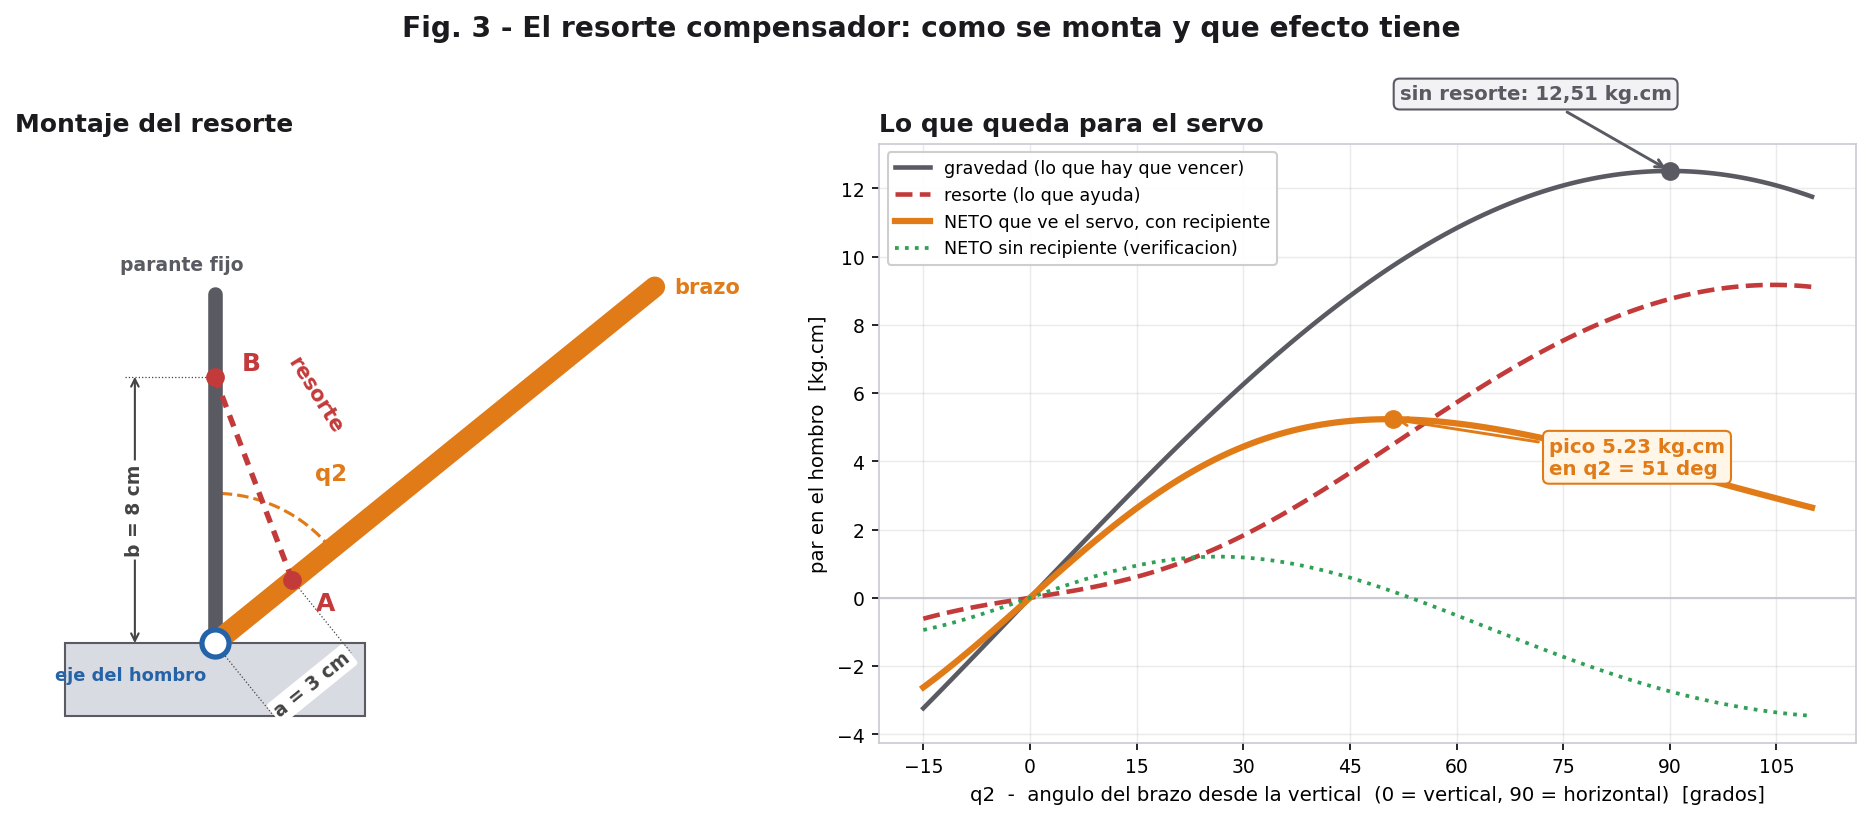

## 8.2 La gravedad en función del ángulo

Hasta acá calculamos el par en una sola pose. Para el resorte necesitamos la
curva completa. Con $q_2$ medido desde la vertical, la distancia horizontal de
cada masa es $d_i \sin q_2$, así que

$$\tau_{\text{grav}}(q_2) = \left[\sum_i m_i\, g\, d_i\right] \sin q_2 = K_{\text{grav}} \sin q_2$$

Toda la sumatoria de la sección 7 es **una sola constante** $K_{\text{grav}}$, y
la dependencia del ángulo es un seno limpio.

## 8.3 La ley del resorte, y por qué encaja tan bien

Montamos un resorte de tracción entre dos puntos:

- **A**, sobre el brazo, a una distancia $a$ del eje del hombro;
- **B**, fijo a la estructura, a una distancia $b$ del eje, **verticalmente
  arriba** (un parante corto al lado del hombro).

Si el resorte fuera ideal, de longitud libre nula ($F = k\,L$), el momento que
produce sobre el hombro se simplifica a

$$\tau_{\text{resorte}} = k \cdot a \cdot b \cdot \sin q_2$$

**Es la misma forma funcional que la gravedad**: el mismo seno, con otra
constante. Cuando lo vimos nos pareció casualidad, pero no lo es: sale de la
geometría, y es el motivo por el que este mecanismo se usa desde hace más de un
siglo.

Entonces la condición de compensación, válida para **todos los ángulos a la
vez**, es una sola ecuación. Si queremos compensar una fracción $\eta$ de la
gravedad:

$$k = \frac{\eta \cdot K_{\text{grav}}}{a \cdot b}$$

## 8.4 Los resortes reales tienen longitud libre

Un resorte de verdad recién empieza a hacer fuerza a partir de su longitud libre
$L_0$: $F = k\,(L - L_0)$. Eso nos mete un factor de corrección que **depende del
ángulo**:

$$\tau_{\text{resorte}}(q_2) = k\,a\,b\,\sin q_2 \left(1 - \frac{L_0}{L_s(q_2)}\right), \qquad L_s(q_2) = \sqrt{a^2 + b^2 - 2ab\cos q_2}$$

La compensación deja de ser perfecta, y tiene una consecuencia que no
esperábamos: **el peor caso se corre y ya no está en 90°**.

## 8.5 Por qué compensamos el 70 % y no el 100 %

Si compensáramos el 100 % con el brazo cargado, al **soltar el recipiente** el
resorte quedaría de más y empujaría el brazo hacia arriba solo: el servo pasaría
de sostener a tener que retener. Con 70 % ese efecto queda chico y el caso
cargado sigue siendo el que manda, que es lo que queremos. La celda de abajo lo
verifica con números.

In [7]:
# ---- Geometria del resorte ----------------------------------------------
A_SP  = 0.030               # m - anclaje sobre el brazo
B_SP  = 0.080               # m - anclaje sobre el parante, arriba del hombro
L0_SP = 0.045               # m - longitud libre del resorte
ETA   = 0.70                # fraccion de la gravedad que compensamos

def largo_resorte(q):
    return math.sqrt(A_SP**2 + B_SP**2 - 2*A_SP*B_SP*math.cos(q))

K_CARGADO = th                                  # N*m, con recipiente
K_VACIO   = pares(m_codo, m_muneca, 0.0)[0]     # N*m, sin recipiente

# Constante elastica que da ETA de compensacion en 90 grados
k = ETA * K_CARGADO / (A_SP * B_SP * (1 - L0_SP / largo_resorte(math.pi/2)))
kab = k * A_SP * B_SP

def tau_resorte(q):
    return kab * math.sin(q) * (1 - L0_SP / largo_resorte(q))

print(f"K_grav con recipiente : {a_kgcm(K_CARGADO):5.2f} kg.cm")
print(f"K_grav sin recipiente : {a_kgcm(K_VACIO):5.2f} kg.cm")
print(f"Constante elastica k  : {k:5.0f} N/m")
print(f"Fuerza maxima         : {k*(largo_resorte(math.radians(110))-L0_SP):5.1f} N "
      f"({k*(largo_resorte(math.radians(110))-L0_SP)/G:.2f} kgf)")
print(f"Largo instalado       : de {largo_resorte(0)*100:.1f} a "
      f"{largo_resorte(math.radians(110))*100:.1f} cm "
      f"(L0 = {L0_SP*100:.1f} cm, nunca queda flojo)")

K_grav con recipiente : 12.51 kg.cm
K_grav sin recipiente :  6.01 kg.cm
Constante elastica k  :   756 N/m
Fuerza maxima         :  37.5 N (3.82 kgf)
Largo instalado       : de 5.0 a 9.5 cm (L0 = 4.5 cm, nunca queda flojo)


In [8]:
print(f"{'q2':>5} {'gravedad':>10} {'resorte':>10} "
      f"{'neto CON':>10} {'neto SIN':>10}")
print(f"{'[deg]':>5} {'[kg.cm]':>10} {'[kg.cm]':>10} "
      f"{'recipiente':>10} {'recipiente':>10}")
print("-" * 50)

peor, q_peor = 0.0, 0
for grados in range(-15, 111):
    q = math.radians(grados)
    ts = tau_resorte(q)
    neto_con = K_CARGADO * math.sin(q) - ts
    neto_sin = K_VACIO   * math.sin(q) - ts
    if max(abs(neto_con), abs(neto_sin)) > peor:
        peor = max(abs(neto_con), abs(neto_sin))
        q_peor = grados
    if grados in (-15, 0, 15, 30, 45, 51, 60, 75, 90, 105, 110):
        print(f"{grados:5} {a_kgcm(K_CARGADO*math.sin(q)):10.2f} "
              f"{a_kgcm(ts):10.2f} {a_kgcm(neto_con):10.2f} "
              f"{a_kgcm(neto_sin):10.2f}")

clase_con, _ = clase_necesaria(peor)
clase_sin, _ = clase_necesaria(K_CARGADO)
print(f"\nPeor caso CON resorte : {a_kgcm(peor):5.2f} kg.cm en q2 = {q_peor} deg"
      f"  -> x FS = {a_kgcm(peor)*FS:5.2f} -> clase {clase_con}")
print(f"Peor caso SIN resorte : {a_kgcm(K_CARGADO):5.2f} kg.cm en q2 = 90 deg"
      f"  -> x FS = {a_kgcm(K_CARGADO)*FS:5.2f} -> clase {clase_sin}")

   q2   gravedad    resorte   neto CON   neto SIN
[deg]    [kg.cm]    [kg.cm] recipiente recipiente
--------------------------------------------------
  -15      -3.24      -0.61      -2.62      -0.94
    0       0.00       0.00       0.00       0.00
   15       3.24       0.61       2.62       0.94
   30       6.26       1.83       4.43       1.18
   45       8.85       3.66       5.18       0.59
   51       9.72       4.49       5.23       0.18
   60      10.83       5.72       5.11      -0.52
   75      12.08       7.54       4.55      -1.73
   90      12.51       8.76       3.75      -2.75
  105      12.08       9.17       2.91      -3.36
  110      11.76       9.11       2.64      -3.46

Peor caso CON resorte :  5.23 kg.cm en q2 = 51 deg  -> x FS = 10.47 -> clase 11
Peor caso SIN resorte : 12.51 kg.cm en q2 = 90 deg  -> x FS = 25.02 -> clase 35


### Qué sacamos de esta tabla

**El resultado principal.** El pico de par en el hombro baja de 12,51 a
**5,23 kg·cm**, y la clase de servo que necesitamos baja de **35 a 11 kg·cm**.
Pasamos de la clase más cara a una de las más baratas sin tocar la geometría ni
la carga.

**El pico se corrió a 51°.** Con un resorte ideal el máximo estaría en 90°; con
uno real, el factor $(1 - L_0/L_s)$ hace que la compensación sea menos efectiva
cuando el brazo está alto, y el peor caso migra a la zona media. Si hubiéramos
dimensionado mirando solo los 90° nos habríamos quedado cortos, y es el tipo de
error que no se nota hasta que el servo se traba.

**La verificación sin recipiente.** La última columna es el caso en que el brazo
está vacío y el resorte sobra. El neto llega a −3,46 kg·cm, y el signo negativo
significa que el servo sujeta hacia abajo en vez de hacia arriba. Es menos que
los 5,23 kg·cm del caso cargado, así que el caso con recipiente sigue gobernando
el dimensionamiento y no necesitamos margen extra. Eso es exactamente lo que nos
compró elegir 70 % en lugar de 100 %.

El resorte que nos queda —unos 750 N/m, 3,8 kgf de fuerza máxima, alrededor de
5 cm de estiramiento— es un resorte de tracción común de ferretería.

---

# 9. Por qué elegimos 12 cm y no otro tamaño

El largo de los eslabones era la otra variable libre. Corrimos el mismo cálculo
completo —con iteración de masas y con resorte— para varios tamaños:

| L₁ = L₂ | Alcance | Par hombro sin resorte | Pico con resorte | Servos (hombro/codo/muñeca) |
|---|---|---|---|---|
| 8 cm | 24,5 cm | 8,7 kg·cm | 3,65 | 9 / 11 / 9 |
| 10 cm | 28,5 cm | 10,6 | 4,45 | 9 / 15 / 9 |
| **12 cm** | **32,5 cm** | **12,5** | **5,23** | **11 / 15 / 9** |
| 14 cm | 36,5 cm | 14,4 | 6,04 | 15 / 15 / 9 |
| 16 cm | 40,5 cm | 16,4 | 6,88 | 15 / 20 / 9 |

**Elegimos 12 cm**, por tres motivos:

- Entre 10 y 12 cm ganamos **4 cm de alcance** y lo único que cambia es el servo
  del hombro, de clase 9 a clase 11: dos clases contiguas que cuestan casi lo
  mismo. Es alcance casi gratis.
- De 12 a 14 cm el hombro ya salta a clase 15 y lo que ganamos es
  proporcionalmente menos.
- Con 32,5 cm de alcance el brazo toma el recipiente en un punto y lo deposita a
  unos 20 cm sin mover la base, que es lo que pide la tarea, y entra cómodo en
  una mesa de trabajo.

Algo que nos llamó la atención: **el resorte cambia la decisión**. Sin él, pasar
de 10 a 12 cm significaba saltar de clase 25 a clase 35. Con resorte es un
escalón chico. O sea que el compensador no solo abarata, además vuelve la
elección de la geometría mucho menos sensible al presupuesto.

---

# 10. Lo que elegimos

| Articulación | Par requerido | × FS 2 | **Clase adoptada** | Masa típica | Comentario |
|---|---|---|---|---|---|
| Base | — | — | **9 kg·cm** | 55 g | Gira sobre un eje vertical, así que no tiene par gravitatorio. La dimensionamos por fricción e inercia. |
| Hombro | 5,23 kg·cm | 10,5 | **11 kg·cm** | 55 g | Con el resorte compensador. Sin él necesitaríamos 35 kg·cm. |
| Codo | 6,59 kg·cm | 13,2 | **15 kg·cm** | 65 g | La articulación más exigente del brazo una vez compensado el hombro. |
| Muñeca | 2,08 kg·cm | 4,2 | **9 kg·cm** | 55 g | Solo carga la pinza y el recipiente. |
| Pinza | pendiente | — | **9 kg·cm** (tentativo) | dentro de los 90 g | Se dimensiona por fuerza de agarre, no por par gravitatorio. Todavía no lo calculamos. |

**Geometría adoptada:** eslabones de 12 cm, muñeca de 8,5 cm, alcance 32,5 cm,
altura del hombro 9 cm.

**Resorte del hombro:** $k \approx 750$ N/m, anclajes a 3 cm sobre el brazo y
8 cm sobre el parante, longitud libre 4,5 cm, compensación 70 %.

### Una observación que nos parece interesante

Después de compensar el hombro, **la articulación más exigente pasa a ser el
codo**. Es contraintuitivo y nos parece un buen resultado: significa que el
resorte corrigió un desbalance que tenía el diseño.

Si más adelante quisiéramos abaratar todavía más, el próximo paso sería un
segundo resorte en el codo, con exactamente la misma cuenta, que lo bajaría a
clase 9. Lo dejamos anotado como mejora posible pero no lo adoptamos ahora, para
no complicar la mecánica en esta etapa.

---

# 11. La base tiene que aguantar el vuelco

Esto no lo teníamos en cuenta al principio y lo agregamos después de revisar el
cálculo entre nosotros. El par de 12,51 kg·cm que calculamos para el hombro
**también existe como momento de vuelco sobre la mesa**: el brazo estirado tiende
a tumbar todo el conjunto hacia adelante.

El resorte no ayuda acá. Es una fuerza interna entre el brazo y el parante, y los
dos están montados sobre la misma base, así que no cambia el momento externo.

Para que el brazo no se tumbe, el peso de la base por su radio tiene que superar
ese momento:

$$m_{\text{base}} \cdot R_{\text{base}} \;\ge\; FS \cdot 12{,}51\ \text{kg·cm}$$

In [9]:
MOMENTO_VUELCO = a_kgcm(K_CARGADO)      # kg.cm, el mismo que ve el hombro
FS_VUELCO = 1.5                         # criterio mas relajado que el de los servos

print(f"Momento de vuelco: {MOMENTO_VUELCO:.2f} kg.cm\n")
print(f"{'radio de la base':>18} {'masa minima':>13}")
print(f"{'[cm]':>18} {'[kg]':>13}")
print("-" * 32)
for R in (7, 10, 12, 15, 20):
    print(f"{R:18.0f} {FS_VUELCO*MOMENTO_VUELCO/R:13.2f}")

Momento de vuelco: 12.51 kg.cm

  radio de la base   masa minima
              [cm]          [kg]
--------------------------------
                 7          2.68
                10          1.88
                12          1.56
                15          1.25
                20          0.94


Los números nos sorprendieron: con una base de 10 cm de radio hacen falta casi
**2 kg** solo de lastre, y eso es más que todo el resto del brazo junto.

Tenemos dos salidas, y elegimos la segunda:

1. **Base pesada**: una chapa o un bloque de unos 2 kg. Funciona, pero el brazo
   deja de ser transportable y sube el costo.
2. **Amurar la base a la mesa** con una morsa o con tornillos pasantes. El
   momento lo toma la mesa y no hace falta lastre. Es lo que vamos a hacer para
   los ensayos.

Lo anotamos como un requerimiento de montaje: **el brazo tiene que estar fijado
a la mesa durante toda la operación**. No es un detalle menor, porque un vuelco
con el recipiente cargado es justamente el accidente que el proyecto quiere
evitar.

---

# 12. Lo que falta verificar, y los modos de falla

Este cálculo es una base para comprar y construir, no una garantía. Dejamos
anotado lo que queda pendiente.

### Ensayos que vamos a hacer

1. **Medir el resorte.** Lo colgamos, le colgamos pesos conocidos y medimos la
   elongación con una regla. Graficando fuerza contra elongación, la pendiente
   nos da $k$ y la ordenada al origen nos da $L_0$: **los dos parámetros de una
   sola medición**. Son 20 minutos y convierte un valor supuesto en un dato
   medido.
2. **Validar una junta.** Un solo servo, una varilla del largo total, una pesa de
   200 g en la punta y el resorte montado. Si levanta y sostiene en todo el
   rango, el cálculo queda confirmado experimentalmente. Son dos horas y nos
   ahorran semanas de análisis.
3. **Pesar el recipiente real** cuando decidamos cuál usamos, y confirmar que
   está por debajo de los 200 g que especificamos.
4. **Dimensionar la pinza** por fuerza de agarre. Es el único servo que todavía
   no calculamos.

### Modos de falla que identificamos

- **Rotura o desenganche del resorte.** El servo del hombro vería de golpe los
  12,51 kg·cm completos, muy por encima de su clase: se trabaría y el brazo
  caería con el recipiente. Lo mitigamos con un tope mecánico que limite la
  caída y con verificación visual del anclaje antes de cada ensayo.
- **Vuelco del conjunto.** Cubierto con la fijación a la mesa de la sección 11.
- **Alimentación insuficiente.** El par que publica el fabricante es a tensión
  máxima. Si alimentamos por debajo de lo especificado, el margen real es menor
  que el calculado.
- **Movimiento más rápido que el de diseño.** Invalida la hipótesis de la
  sección 3.4: si algún tramo se hace en menos tiempo que el mínimo de esa
  tabla, la parte dinámica deja de ser despreciable y hay que rehacer todo el
  dimensionamiento.

### Sobre el factor de seguridad de 2

No lo elegimos al azar. Cubre cuatro incertidumbres que no podemos cuantificar
con los datos que tenemos:

1. el par que se publica es de **rotor bloqueado**, no continuo;
2. está medido a la **tensión máxima** del servo;
3. los engranajes tienen **dispersión de fabricación** y se desgastan con el uso;
4. nuestras masas son **estimaciones**, no mediciones.

Ese es justamente el valor de un factor de seguridad: nos permite no calcular lo
que no podemos calcular bien.